# IMT 573 - Final Examination


Points: 100

Name: Justin Mathews

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Justin Mathews 

11/28/2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [38]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [40]:
affairs.head()


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [18]:
affairs['children'].mean()

1.3968740182218033

In [20]:
affairs['age'].mean()

29.082862079798932

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [42]:
affairs['engaged_affair'] = (affairs['affairs'] > 0).astype(int)

affairs[['affairs', 'engaged_affair']].head()


,affairs,engaged_affair
0,0.111111,1
1,3.230769,1
2,1.400000,1
3,0.727273,1
4,4.666666,1


(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [64]:
# predictors for who had affair
x = affairs[['rate_marriage', 'age', 'yrs_married', 'children',
                   'religious', 'educ', 'occupation', 'occupation_husb']]
x = sm.add_constant(x)   
y = affairs['engaged_affair']

# fit logistic regression
model = sm.Logit(y, x).fit()
model.summary()





Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         engaged_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1327
Time:                        20:47:57   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7257      0.299     12.470      0.000       3.140       4.311
rate_marriage      -0.7161      0.031    -22.784      0.000      -0.778      -0.655
age                -0.0605      0.010     -5.885      0.000      -0.081      -0.040
yrs_married         0.1100      0.011     10.054      0.000       0.089       0.131
children           -0.0042      0.032     -0.134      0.893      -0.066       0.058
religious          -0.3752      0.035    -10.792      0.000      -0.443      -0.307
educ               -0.0392      0.015     -2.533      0.011      -0.070      -0.009
occupation          0.1602      0.034      4.717      0.000       0.094       0.227
occupation_husb     0.0124      0.023      0.541      0.589      -0.033       0.057
===================================================================================
"""

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [70]:
# to get the "best fit" model, taking out variables with high p values - children,occ_husb
best = affairs[['rate_marriage', 'age', 'yrs_married',
                  'religious', 'educ', 'occupation']] 

best = sm.add_constant(best)
y = affairs['engaged_affair']

model2 = sm.Logit(y, best).fit()
print(b_model.summary())

Optimization terminated successfully.
         Current function value: 0.545339
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         engaged_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1326
Time:                        20:54:07   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.7371      0.296     12.622      0.000       3.157       4.317
rate_marriage    -0.

(e) Interpret the model parameters using the model from part (d).

# In the model parameters, I notice the direction of the effects. The marriage rating for example has a bigger negative number – points to the idea that people who feel better about their marriage are less likely to have an affair. Age is also negative, and makes me think younger people in this dataset might be more at risk. We see religious being negative as well, so it seems that more religious folk seem to be less likely to have an affair. Education is negative too, but not by a whole lot so I’m not sure if we should interpret this to have a big effect. On the other side length of time married and occupation both are positive so being married longer or having a more senior job looks like it increases the chance of cheating. I’m mostly looking at these positive or negative coefficients to help guide my thought process, and they do make some level of sense. 


(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

In [87]:
# check model parameters
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         engaged_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1326
Time:                        21:13:48   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.7371      0.296     12.622      0.000       3.157       4.317
rate_marriage    -0.7153      0.031    -22.804      0.000      -0.777      -0.654
age              -0.0602      0.010     -5.867      0.000      -0.080      -0.040
yrs_married       0.1095      0.010     11.237      0.000       0.090       0.129
religious        -0.3760      0.035    -10.856      0.000      -0.444      -0.308
educ             -0.0380      0.015     -2.482      0.013      -0.068      -0.008
occupation        0.1628      0.034      4.838      0.000       0.097       0.229
=================================================================================
"""

In [78]:
np.random.seed(2025)

# make test data w
test_data = pd.DataFrame({
    'rate_marriage': np.random.randint(1, 6, 200),
    'age': affairs['age'].mean(),
    'yrs_married': affairs['yrs_married'].mean(),
    'religious': affairs['religious'].mean(),
    'educ': affairs['educ'].mean(),
    'occupation': affairs['occupation'].mean()
})
# add constant for intercept
test_data['const'] = 1

# get predictions - to match order from the model
predictions = model2.predict(test_data[['const', 'rate_marriage', 'age',
                                         'yrs_married', 'religious', 'educ', 'occupation']])

test_data['pred_prob'] = predictions
test_data.head(10)

,rate_marriage,age,yrs_married,religious,educ,occupation,const,pred_prob
0,3,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.482895
1,5,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.182573
2,1,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.796104
3,4,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.313517
4,4,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.313517
5,5,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.182573
6,1,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.796104
7,1,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.796104
8,3,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.482895
9,2,29.082862,9.009425,2.42617,14.209865,3.424128,1,0.656297


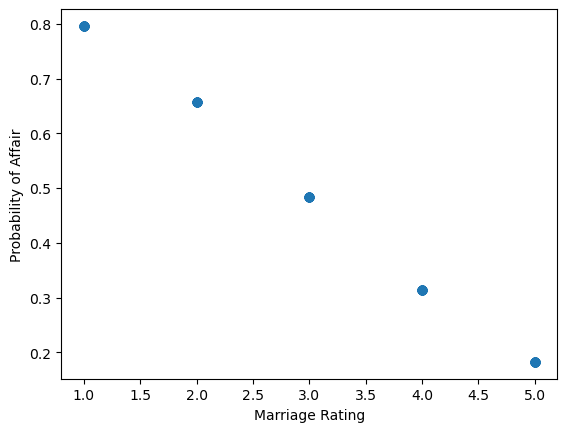

In [85]:
# visualization 

plt.scatter(test_data['rate_marriage'], test_data['pred_prob'])
plt.xlabel('Marriage Rating')
plt.ylabel('Probability of Affair')
plt.show()

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

# From the plot it seems like the probability of having an affair goes down as the marriage rating goes up. People who rate their marriage a 1 or 2 seem more likely to have an affair compared to people who rate it closer to a 4 or 5. The line isn’t perfect straight, but the trend seems quite negative. I’m not totally sure how strong the pattern really is since the probabilities don’t drop by a huge amount.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [94]:
from ISLP import load_data
Hitters = load_data('Hitters')

###Hitters.head()

(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

In [96]:
from ISLP import load_data
Hitters = load_data('Hitters')


Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
#Is the player salary related to the amount of years they played in the league? 

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

# This data has a bunch of baseball stats. These stats include years they’ve been playing and their salary, which I need for my question. I noticed that some salary values are missing, specifically the first row says Nan. Since my question is comparing salary to years in the league, I’ll need to drop those missing salary rows. Aside from this, the dataset looks ok to use.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

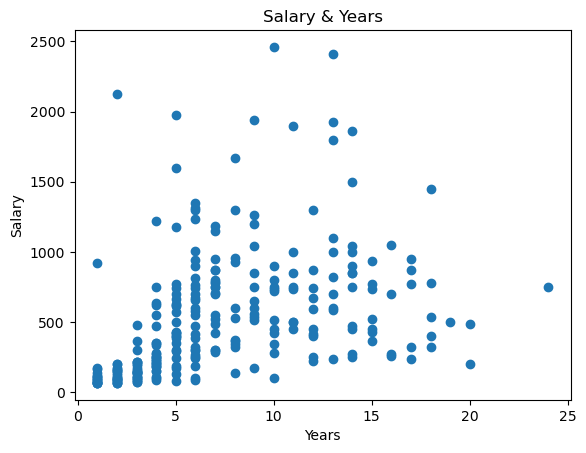

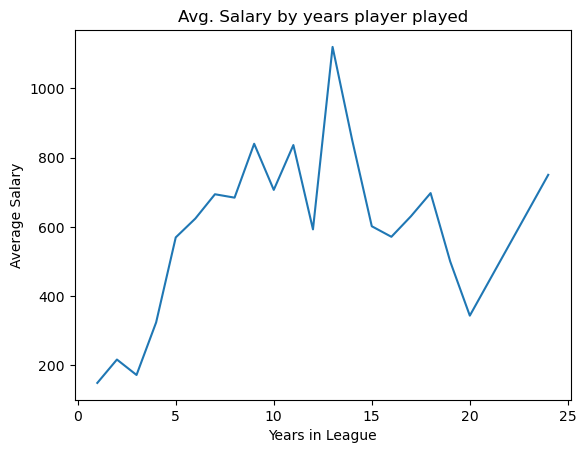

In [102]:
# remove missing salaries 
clean = Hitters.dropna(subset=['Salary'])


# first visualization, scatter plot
plt.scatter(clean['Years'], clean['Salary'])
plt.xlabel('Years')
plt.ylabel('Salary')
plt.title('Salary & Years')
plt.show()

#second visualization, average by years 
avg_salary = clean.groupby('Years')['Salary'].mean()

plt.plot(avg_salary)
plt.xlabel('Years in League')
plt.ylabel('Average Salary')
plt.title('Avg. Salary by years player played')
plt.show()




(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

# From the charts, I was mostly able to answer my question about whether more years in the league translates to higher salary. The scatterplot for sure has some variation, but players with only a few years of experience usually do earn less. Salaries seem to increase as players progress in experience especially in the early to mid range of their careers. The second chart showing average salary by years played definitely makes it clearer and solidifies this argument. The data is good enough to study this basic pattern even though some values were missing. To be fair, salary is probably influenced by other things too, but this analysis gives me enough information to answer the question in a simple way.

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

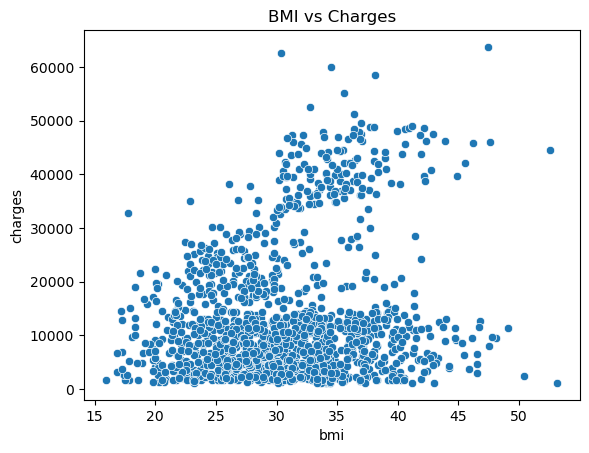

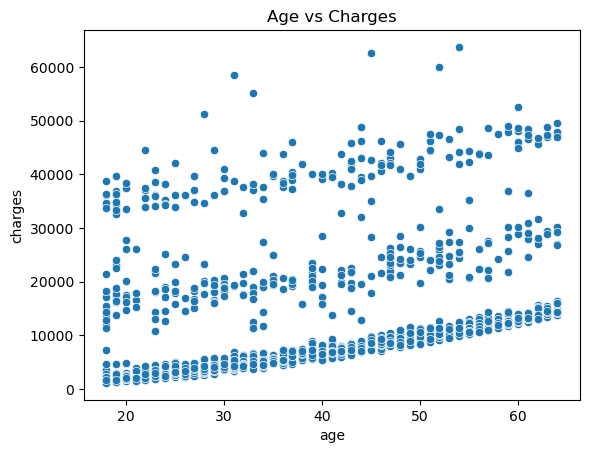

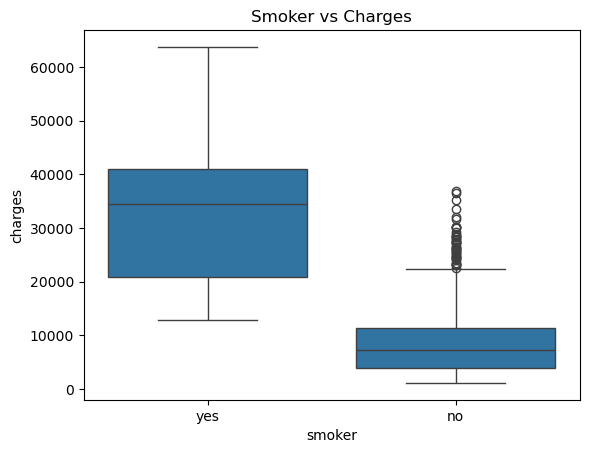

In [11]:
df = pd.read_csv('insurance.csv')

# charges - BMI
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('BMI vs Charges')
plt.show()

# charges - Age
sns.scatterplot(data=df, x='age', y='charges')
plt.title('Age vs Charges')
plt.show()

# charges - smoker or not
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Smoker vs Charges')
plt.show()


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

# For BMI the plot was spread out overall.  There does seem to be a slight pattern, although its kind of hard to read where people with higher BMI seem to have higher medical charges. I guess the best way to describe is that you can see that some of the highest charges happen for people with BMI in the 30+ range. It does seem to have some relation with charges. For age, there was also quite a bit of noise. Seemingly, charges do increase a little as age goes up. Older people seem to have more cases with high charges. So, age might matter a little but not in a very strong or clean way based on the scatterplot. The relationship isn’t super clear. Smokers had the clearest result; they had noticeably higher medical charges. The medium level of charges, and the overall spread shows a clear indicator of higher charges for smokers. So we can conclude pretty confidently that being a smoker is related with significantly higher medical expenses.

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [13]:
# fit regression with bmi
x = df[['bmi']]
x = sm.add_constant(x)
charges = df['charges']

bmi = sm.OLS(y, x).fit()
bmi.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           2.46e-13
Time:                        22:48:46   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.474   -2072.974    4458.849
bmi          393.8730     53.251      7.397      0.000     289.409     498.337
==============================================================================
Omnibus:                      261.030   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              431.091
Skew:                           1.297   Prob(JB):                     2.45e-94
Kurtosis:                       4.004   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

# For the regression output for bmi, I’m not sure everything is perfect with the assumptions. The scatterplot actually didn’t really look like a clean straight line, so the relationship between bmi and charges probably isn’t a strong linear one. The R squared is tiny, about 0.04, which shows BMI barely explains anything, so the model is could be missing other things that affects medical costs.


(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [71]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

df = pd.read_csv(location + dataframe, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [76]:
df.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
dtype: int64

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

# One application is whether a student will pass or fail a class. It would be based on things like homework scores or test grades. The response here would be “pass or fail,” and I think it is more prediction since we would mainly want to know the expected outcome. 

# I think medical diagnosing is another good application here. This could be based on symptoms, assessments, lab results, or imaging to then determine that a patient has or may have a certain disease. The specific response likely would be “positive or negative,” and the goal can be both inference and prediction. Doctors  want to understand which factors matter, but they also care about accurate predictions. 

# The last example I was thinking of is predicting whether a patient will need to return for care. The predictors could include past visits, history, age, insurance, or the level of illness or condition. This is mostly prediction because the goal is to anticipate patient behavior.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

# For regression a good example is predicting restaurant wait times. You could predict time of day, parties waiting, weekday, and restaurant size. The response is in minutes, and the goal is mainly prediction because customers want a time estimate of waiting time. Another example is predicting uber pricing using distance, travel time, time of day, and surge. This is mainly prediction because the company wants to estimate prices for the rider accurately. A third example is predicting a patient’s recovery time after a visit. We’d use things like age or procedure type. This can use inference and prediction since hospitals want to understand which factors affect recovery but also create accurate estimates. 

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

# From my understanding flexible models fit the data more closely while less flexible models stay simpler. Flexible models can capture complex patterns but might overfit. Less flexible models have more room for interpretation but might miss important relationships. I think flexible approaches work better when you have lots of data with complicated patterns. 


### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

In [ ]:
# The correct answer is iii

# In the model X3 is gender, X5 is the interaction between gpa and gender. B5 = -10 is the interaction and B5 is negative, so females lose 10k for gpa compared to males. In the equation we plug in the values for male and female at 0 and 1. B3 = 35, and since male value is 0, females get a $35k head start. When we subtract the equations and compare male - female salary, we get -35 + 10(gpa). When we test values, and the gpa gets to 3.5, we get a result of 0, so they earn the same amount. Above 3.5, the result is positive, so males earn more. So iii makes sense - when gpa is high enough, specifically higher than 3.5, males earn more. 

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

In [ ]:
# 50+ 20(4.0)+0.07(110)+35(1)+0.01(4.0x110)-10(4.0x1) --> 50+80+7.7+35+4.4 -40 =137.1 

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

In [ ]:
# True, the gpa/iq interaction is 0.01 and pretty tiny. compared to the other coeffecients like 20 for gpa, or 35 for gender,it is quite small, and should have litttle interaction effect.   

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [ ]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  